## NSL-KDD Datset Preview (Overall, Rare)

Attack Type:

2L and U2R attacks

NSL-KDD Common R2L & U2R Attacks Analysis
Loading NSL-KDD Training and Testing Data...
--------------------------------------------------
Loading training data from: ../raw/NSL_KDD_DATASET/KDDTrain+.TXT
✓ Training data loaded: (125973, 43)
Loading test data from: ../raw/NSL_KDD_DATASET/KDDTest+.TXT
✓ Test data loaded: (22544, 43)

FINDING COMMON R2L & U2R ATTACKS

R2L ATTACKS ANALYSIS:
----------------------------------------
✓ ftp_write           : Train=     8, Test=     3, Total=    11
✓ guess_passwd        : Train=    53, Test= 1,231, Total= 1,284
✓ imap                : Train=    11, Test=     1, Total=    12
✓ multihop            : Train=     7, Test=    18, Total=    25
✓ phf                 : Train=     4, Test=     2, Total=     6
⚠ spy                 : Train=     2, Test=     0 (Train only)
⚠ warezclient         : Train=   890, Test=     0 (Train only)
✓ warezmaster         : Train=    20, Test=   944, Total=   964
⚠ sendmail            : Train=     0, Test=    14 (Test only

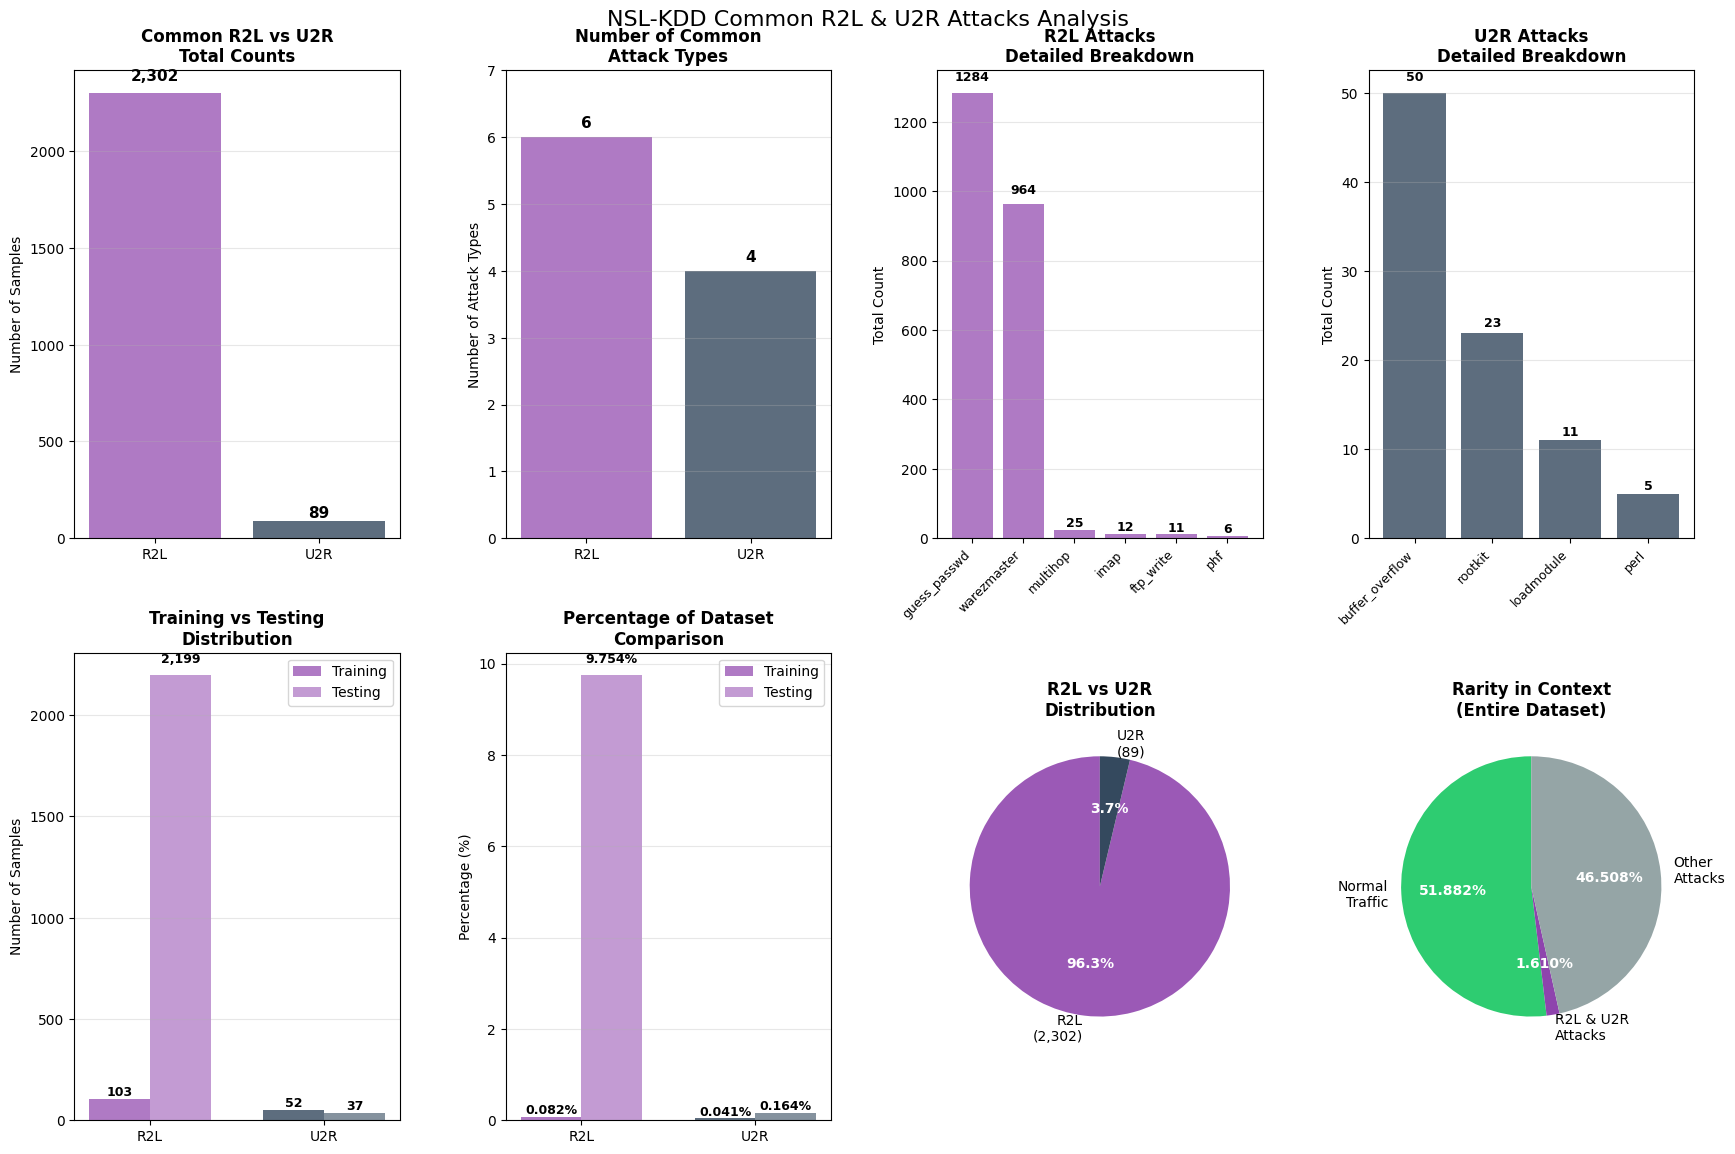


FOCUSED ANALYSIS REPORT: COMMON R2L & U2R ATTACKS

🎯 KEY FINDINGS:
   • Total common R2L attacks: 2,302
   • Total common U2R attacks: 89
   • Combined rare attacks: 2,391
   • Percentage of total dataset: 1.6099%

📊 ATTACK TYPE BREAKDOWN:

R2L ATTACKS:
   • Number of common attack types: 6
   • Total samples: 2,302
   • Most frequent: guess_passwd (1,284 samples)
   • Least frequent: phf (6 samples)

U2R ATTACKS:
   • Number of common attack types: 4
   • Total samples: 89
   • Most frequent: buffer_overflow (50 samples)
   • Least frequent: perl (5 samples)

🔍 RARITY ASSESSMENT:
   • Rarity ratio: 1 rare attack per 62.1 total samples
   • These attacks represent the truly rare events in cybersecurity
   • Critical for testing anomaly detection systems

ANALYSIS COMPLETE!
Common R2L & U2R attacks have been identified and analyzed.
Visualizations have been created and saved.

You can now access:
• train_data, test_data - Original datasets
• common_attacks - Common attacks data structu

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from collections import defaultdict

# Set style for better-looking plots
plt.style.use('default')
sns.set_palette("husl")

# Define the dataset folder path
DATASET_FOLDER = "../raw/NSL_KDD_DATASET/"

# Define the column names for NSL-KDD TXT files
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
    'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'attack_type', 'difficulty_level'
]

def get_rare_attack_categories():
    """Define R2L and U2R attack categories"""
    return {
        'R2L': ['ftp_write', 'guess_passwd', 'imap', 'multihop', 'phf', 'spy', 'warezclient', 'warezmaster', 
                'sendmail', 'named', 'snmpgetattack', 'snmpguess', 'xlock', 'xsnoop', 'httptunnel'],
        'U2R': ['buffer_overflow', 'loadmodule', 'perl', 'rootkit', 'ps', 'sqlattack', 'xterm']
    }

def get_colors():
    """Define colors for R2L and U2R"""
    return {
        'R2L': '#9b59b6',      # Purple
        'U2R': '#34495e'       # Dark gray
    }

def load_datasets():
    """Load training and testing datasets"""
    print("Loading NSL-KDD Training and Testing Data...")
    print("-" * 50)
    
    # Load training data
    train_file = os.path.join(DATASET_FOLDER, "KDDTrain+.TXT")
    print(f"Loading training data from: {train_file}")
    try:
        train_data = pd.read_csv(train_file, names=column_names, skipinitialspace=True)
        train_data['attack_type'] = train_data['attack_type'].str.rstrip('.')
        print(f"✓ Training data loaded: {train_data.shape}")
    except Exception as e:
        print(f"✗ Error loading training data: {e}")
        return None, None
    
    # Load test data
    test_file = os.path.join(DATASET_FOLDER, "KDDTest+.TXT")
    print(f"Loading test data from: {test_file}")
    try:
        test_data = pd.read_csv(test_file, names=column_names, skipinitialspace=True)
        test_data['attack_type'] = test_data['attack_type'].str.rstrip('.')
        print(f"✓ Test data loaded: {test_data.shape}")
    except Exception as e:
        print(f"✗ Error loading test data: {e}")
        return train_data, None
    
    return train_data, test_data

def find_common_rare_attacks(train_data, test_data):
    """
    Find R2L and U2R attacks that appear in both training and testing sets
    
    Args:
        train_data (pd.DataFrame): Training dataset
        test_data (pd.DataFrame): Testing dataset
    
    Returns:
        dict: Common attacks by category with their counts
    """
    categories = get_rare_attack_categories()
    
    print("\n" + "=" * 80)
    print("FINDING COMMON R2L & U2R ATTACKS")
    print("=" * 80)
    
    common_attacks = {}
    
    for category, attack_list in categories.items():
        print(f"\n{category} ATTACKS ANALYSIS:")
        print("-" * 40)
        
        # Find attacks present in both datasets
        train_attacks = set(train_data['attack_type'].unique())
        test_attacks = set(test_data['attack_type'].unique())
        
        category_common = []
        category_train_only = []
        category_test_only = []
        
        for attack in attack_list:
            in_train = attack in train_attacks
            in_test = attack in test_attacks
            
            train_count = (train_data['attack_type'] == attack).sum() if in_train else 0
            test_count = (test_data['attack_type'] == attack).sum() if in_test else 0
            
            if in_train and in_test:
                category_common.append({
                    'attack': attack,
                    'train_count': train_count,
                    'test_count': test_count,
                    'total_count': train_count + test_count
                })
                print(f"✓ {attack:<20}: Train={train_count:>6,}, Test={test_count:>6,}, Total={train_count + test_count:>6,}")
            elif in_train:
                category_train_only.append((attack, train_count))
                print(f"⚠ {attack:<20}: Train={train_count:>6,}, Test={test_count:>6,} (Train only)")
            elif in_test:
                category_test_only.append((attack, test_count))
                print(f"⚠ {attack:<20}: Train={train_count:>6,}, Test={test_count:>6,} (Test only)")
            else:
                print(f"✗ {attack:<20}: Train={train_count:>6,}, Test={test_count:>6,} (Not found)")
        
        common_attacks[category] = {
            'common': category_common,
            'train_only': category_train_only,
            'test_only': category_test_only
        }
        
        print(f"\nSUMMARY for {category}:")
        print(f"  • Common attacks: {len(category_common)}")
        print(f"  • Train-only attacks: {len(category_train_only)}")
        print(f"  • Test-only attacks: {len(category_test_only)}")
    
    return common_attacks

def analyze_common_rare_attacks(train_data, test_data, common_attacks):
    """
    Detailed analysis of common R2L and U2R attacks
    
    Args:
        train_data (pd.DataFrame): Training dataset
        test_data (pd.DataFrame): Testing dataset
        common_attacks (dict): Common attacks data
    
    Returns:
        dict: Analysis results
    """
    print("\n" + "=" * 80)
    print("DETAILED ANALYSIS OF COMMON R2L & U2R ATTACKS")
    print("=" * 80)
    
    analysis_results = {}
    
    for category in ['R2L', 'U2R']:
        print(f"\n{'='*20} {category} ATTACKS {'='*20}")
        
        common_list = common_attacks[category]['common']
        
        if not common_list:
            print(f"No common {category} attacks found between training and testing sets.")
            analysis_results[category] = {'total_common': 0, 'attacks': []}
            continue
        
        # Sort by total count (descending)
        common_list.sort(key=lambda x: x['total_count'], reverse=True)
        
        total_train_count = sum(attack['train_count'] for attack in common_list)
        total_test_count = sum(attack['test_count'] for attack in common_list)
        total_combined = total_train_count + total_test_count
        
        print(f"\nCOMMON {category} ATTACKS BREAKDOWN:")
        print(f"{'Attack Type':<20} {'Train':<8} {'Test':<8} {'Total':<8} {'Train %':<8} {'Test %':<8}")
        print("-" * 70)
        
        for attack in common_list:
            attack_name = attack['attack']
            train_count = attack['train_count']
            test_count = attack['test_count']
            total_count = attack['total_count']
            
            train_pct = (train_count / len(train_data)) * 100 if len(train_data) > 0 else 0
            test_pct = (test_count / len(test_data)) * 100 if len(test_data) > 0 else 0
            
            print(f"{attack_name:<20} {train_count:<8,} {test_count:<8,} {total_count:<8,} {train_pct:<8.4f} {test_pct:<8.4f}")
        
        print(f"\n{category} TOTALS:")
        print(f"  • Total {category} in training: {total_train_count:,}")
        print(f"  • Total {category} in testing: {total_test_count:,}")
        print(f"  • Combined total: {total_combined:,}")
        print(f"  • Training set percentage: {(total_train_count/len(train_data))*100:.4f}%")
        print(f"  • Testing set percentage: {(total_test_count/len(test_data))*100:.4f}%")
        
        analysis_results[category] = {
            'total_common': len(common_list),
            'total_train_count': total_train_count,
            'total_test_count': total_test_count,
            'total_combined': total_combined,
            'attacks': common_list
        }
    
    # Overall summary
    print(f"\n{'='*25} OVERALL SUMMARY {'='*25}")
    r2l_total = analysis_results.get('R2L', {}).get('total_combined', 0)
    u2r_total = analysis_results.get('U2R', {}).get('total_combined', 0)
    grand_total = r2l_total + u2r_total
    
    print(f"Common R2L attacks total: {r2l_total:,}")
    print(f"Common U2R attacks total: {u2r_total:,}")
    print(f"Grand total rare attacks: {grand_total:,}")
    print(f"Percentage of combined dataset: {(grand_total/(len(train_data) + len(test_data)))*100:.4f}%")
    
    analysis_results['summary'] = {
        'r2l_total': r2l_total,
        'u2r_total': u2r_total,
        'grand_total': grand_total,
        'combined_dataset_size': len(train_data) + len(test_data)
    }
    
    return analysis_results

def plot_common_rare_attacks(train_data, test_data, common_attacks, analysis_results, save_plots=False):
    """
    Create comprehensive visualizations for common R2L and U2R attacks
    
    Args:
        train_data (pd.DataFrame): Training dataset
        test_data (pd.DataFrame): Testing dataset
        common_attacks (dict): Common attacks data
        analysis_results (dict): Analysis results
        save_plots (bool): Whether to save plots
    """
    
    fig = plt.figure(figsize=(18, 12))
    colors = get_colors()
    
    # 1. Overview: R2L vs U2R totals
    ax1 = plt.subplot(2, 4, 1)
    plot_category_totals(analysis_results, ax1, colors)
    
    # 2. Common attacks comparison
    ax2 = plt.subplot(2, 4, 2)
    plot_common_attacks_comparison(common_attacks, ax2, colors)
    
    # 3. R2L attacks detailed
    ax3 = plt.subplot(2, 4, 3)
    plot_category_detailed(common_attacks['R2L']['common'], 'R2L', ax3, colors['R2L'])
    
    # 4. U2R attacks detailed
    ax4 = plt.subplot(2, 4, 4)
    plot_category_detailed(common_attacks['U2R']['common'], 'U2R', ax4, colors['U2R'])
    
    # 5. Train vs Test distribution
    ax5 = plt.subplot(2, 4, 5)
    plot_train_test_distribution(analysis_results, ax5, colors)
    
    # 6. Percentage comparison
    ax6 = plt.subplot(2, 4, 6)
    plot_percentage_comparison(train_data, test_data, analysis_results, ax6, colors)
    
    # 7. Combined pie chart
    ax7 = plt.subplot(2, 4, 7)
    plot_combined_pie_chart(analysis_results, ax7, colors)
    
    # 8. Rarity visualization
    ax8 = plt.subplot(2, 4, 8)
    plot_rarity_context(train_data, test_data, analysis_results, ax8, colors)
    
    plt.tight_layout(pad=3.0)
    plt.suptitle('NSL-KDD Common R2L & U2R Attacks Analysis', fontsize=16, y=0.98)
    
    if save_plots:
        plt.savefig('nsl_kdd_common_r2l_u2r_attacks.png', dpi=300, bbox_inches='tight')
        print("Common R2L & U2R analysis saved as 'nsl_kdd_common_r2l_u2r_attacks.png'")
    
    plt.show()

def plot_category_totals(analysis_results, ax, colors):
    """Plot total counts for R2L vs U2R"""
    categories = ['R2L', 'U2R']
    totals = [analysis_results[cat]['total_combined'] for cat in categories]
    bar_colors = [colors[cat] for cat in categories]
    
    bars = ax.bar(categories, totals, color=bar_colors, alpha=0.8)
    
    # Add value labels
    for bar, total in zip(bars, totals):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
               f'{total:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax.set_title('Common R2L vs U2R\nTotal Counts', fontweight='bold', fontsize=12)
    ax.set_ylabel('Number of Samples')
    ax.grid(axis='y', alpha=0.3)

def plot_common_attacks_comparison(common_attacks, ax, colors):
    """Plot comparison of number of common attacks"""
    categories = ['R2L', 'U2R']
    common_counts = [len(common_attacks[cat]['common']) for cat in categories]
    bar_colors = [colors[cat] for cat in categories]
    
    bars = ax.bar(categories, common_counts, color=bar_colors, alpha=0.8)
    
    # Add value labels
    for bar, count in zip(bars, common_counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
               f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax.set_title('Number of Common\nAttack Types', fontweight='bold', fontsize=12)
    ax.set_ylabel('Number of Attack Types')
    ax.set_ylim(0, max(common_counts) + 1)
    ax.grid(axis='y', alpha=0.3)

def plot_category_detailed(attacks_list, category, ax, color):
    """Plot detailed breakdown for a category"""
    if not attacks_list:
        ax.text(0.5, 0.5, f'No common\n{category} attacks', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12, fontweight='bold')
        ax.set_title(f'{category} Attacks\nDetailed Breakdown', fontweight='bold', fontsize=12)
        return
    
    # Sort by total count
    sorted_attacks = sorted(attacks_list, key=lambda x: x['total_count'], reverse=True)
    
    attack_names = [attack['attack'] for attack in sorted_attacks]
    total_counts = [attack['total_count'] for attack in sorted_attacks]
    
    bars = ax.bar(range(len(attack_names)), total_counts, color=color, alpha=0.8)
    
    # Add value labels
    for bar, count in zip(bars, total_counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
               f'{count}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_title(f'{category} Attacks\nDetailed Breakdown', fontweight='bold', fontsize=12)
    ax.set_ylabel('Total Count')
    ax.set_xticks(range(len(attack_names)))
    ax.set_xticklabels(attack_names, rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

def plot_train_test_distribution(analysis_results, ax, colors):
    """Plot training vs testing distribution"""
    categories = ['R2L', 'U2R']
    train_counts = [analysis_results[cat]['total_train_count'] for cat in categories]
    test_counts = [analysis_results[cat]['total_test_count'] for cat in categories]
    
    x = np.arange(len(categories))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, train_counts, width, label='Training', 
                   color=[colors[cat] for cat in categories], alpha=0.8)
    bars2 = ax.bar(x + width/2, test_counts, width, label='Testing', 
                   color=[colors[cat] for cat in categories], alpha=0.6)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                       f'{int(height):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_title('Training vs Testing\nDistribution', fontweight='bold', fontsize=12)
    ax.set_ylabel('Number of Samples')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

def plot_percentage_comparison(train_data, test_data, analysis_results, ax, colors):
    """Plot percentage of dataset comparison"""
    categories = ['R2L', 'U2R']
    
    train_percentages = []
    test_percentages = []
    
    for cat in categories:
        train_pct = (analysis_results[cat]['total_train_count'] / len(train_data)) * 100
        test_pct = (analysis_results[cat]['total_test_count'] / len(test_data)) * 100
        train_percentages.append(train_pct)
        test_percentages.append(test_pct)
    
    x = np.arange(len(categories))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, train_percentages, width, label='Training', 
                   color=[colors[cat] for cat in categories], alpha=0.8)
    bars2 = ax.bar(x + width/2, test_percentages, width, label='Testing', 
                   color=[colors[cat] for cat in categories], alpha=0.6)
    
    # Add value labels
    for bars, percentages in [(bars1, train_percentages), (bars2, test_percentages)]:
        for bar, pct in zip(bars, percentages):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                   f'{pct:.3f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_title('Percentage of Dataset\nComparison', fontweight='bold', fontsize=12)
    ax.set_ylabel('Percentage (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

def plot_combined_pie_chart(analysis_results, ax, colors):
    """Plot pie chart of R2L vs U2R distribution"""
    r2l_total = analysis_results['R2L']['total_combined']
    u2r_total = analysis_results['U2R']['total_combined']
    
    if r2l_total == 0 and u2r_total == 0:
        ax.text(0.5, 0.5, 'No common\nrare attacks', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12, fontweight='bold')
        ax.set_title('R2L vs U2R\nDistribution', fontweight='bold', fontsize=12)
        return
    
    sizes = [r2l_total, u2r_total]
    labels = [f'R2L\n({r2l_total:,})', f'U2R\n({u2r_total:,})']
    pie_colors = [colors['R2L'], colors['U2R']]
    
    # Filter out zero values
    filtered_data = [(size, label, color) for size, label, color in zip(sizes, labels, pie_colors) if size > 0]
    
    if filtered_data:
        sizes, labels, pie_colors = zip(*filtered_data)
        wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%', 
                                         colors=pie_colors, startangle=90)
        
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
    
    ax.set_title('R2L vs U2R\nDistribution', fontweight='bold', fontsize=12)

def plot_rarity_context(train_data, test_data, analysis_results, ax, colors):
    """Plot rarity in context of entire dataset"""
    total_samples = len(train_data) + len(test_data)
    normal_count = (train_data['attack_type'] == 'normal').sum() + (test_data['attack_type'] == 'normal').sum()
    
    rare_total = analysis_results['summary']['grand_total']
    other_attacks = total_samples - normal_count - rare_total
    
    sizes = [normal_count, rare_total, other_attacks]
    labels = ['Normal\nTraffic', 'R2L & U2R\nAttacks', 'Other\nAttacks']
    pie_colors = ['#2ecc71', '#8e44ad', '#95a5a6']
    
    # Filter out zero values
    filtered_data = [(size, label, color) for size, label, color in zip(sizes, labels, pie_colors) if size > 0]
    sizes, labels, pie_colors = zip(*filtered_data)
    
    wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.3f%%', 
                                     colors=pie_colors, startangle=90)
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    ax.set_title('Rarity in Context\n(Entire Dataset)', fontweight='bold', fontsize=12)

def create_focused_analysis_report(analysis_results):
    """Generate a focused report on common R2L and U2R attacks"""
    print("\n" + "=" * 80)
    print("FOCUSED ANALYSIS REPORT: COMMON R2L & U2R ATTACKS")
    print("=" * 80)
    
    summary = analysis_results['summary']
    
    print(f"\n🎯 KEY FINDINGS:")
    print(f"   • Total common R2L attacks: {summary['r2l_total']:,}")
    print(f"   • Total common U2R attacks: {summary['u2r_total']:,}")
    print(f"   • Combined rare attacks: {summary['grand_total']:,}")
    print(f"   • Percentage of total dataset: {(summary['grand_total']/summary['combined_dataset_size'])*100:.4f}%")
    
    print(f"\n📊 ATTACK TYPE BREAKDOWN:")
    for category in ['R2L', 'U2R']:
        category_data = analysis_results[category]
        print(f"\n{category} ATTACKS:")
        print(f"   • Number of common attack types: {category_data['total_common']}")
        print(f"   • Total samples: {category_data['total_combined']:,}")
        
        if category_data['attacks']:
            print(f"   • Most frequent: {category_data['attacks'][0]['attack']} ({category_data['attacks'][0]['total_count']:,} samples)")
            print(f"   • Least frequent: {category_data['attacks'][-1]['attack']} ({category_data['attacks'][-1]['total_count']:,} samples)")
    
    print(f"\n🔍 RARITY ASSESSMENT:")
    if summary['grand_total'] > 0:
        rarity_ratio = summary['combined_dataset_size'] / summary['grand_total']
        print(f"   • Rarity ratio: 1 rare attack per {rarity_ratio:.1f} total samples")
        print(f"   • These attacks represent the truly rare events in cybersecurity")
        print(f"   • Critical for testing anomaly detection systems")
    else:
        print(f"   • No common rare attacks found between datasets")

def main():
    """Main function to run the focused R2L & U2R analysis"""
    print("NSL-KDD Common R2L & U2R Attacks Analysis")
    print("=" * 60)
    
    # Load datasets
    train_data, test_data = load_datasets()
    
    if train_data is None or test_data is None:
        print("Failed to load datasets. Please check file paths.")
        return None, None, None
    
    # Find common attacks
    common_attacks = find_common_rare_attacks(train_data, test_data)
    
    # Analyze common attacks
    analysis_results = analyze_common_rare_attacks(train_data, test_data, common_attacks)
    
    # Create visualizations
    plot_common_rare_attacks(train_data, test_data, common_attacks, analysis_results, save_plots=False)
    
    # Generate focused report
    create_focused_analysis_report(analysis_results)
    
    return train_data, test_data, common_attacks, analysis_results

# Example usage
if __name__ == "__main__":
    # Run focused analysis
    train_data, test_data, common_attacks, analysis_results = main()
    
    print(f"\n{'='*60}")
    print("ANALYSIS COMPLETE!")
    print("="*60)
    print("Common R2L & U2R attacks have been identified and analyzed.")
    print("Visualizations have been created and saved.")
    print("\nYou can now access:")
    print("• train_data, test_data - Original datasets")
    print("• common_attacks - Common attacks data structure")
    print("• analysis_results - Detailed analysis results")

## Extract Rate Attack Dataset

In [5]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Define the dataset folder path
DATASET_FOLDER = "../raw/NSL_KDD_DATASET/"
OUTPUT_FOLDER = "../raw/"

# Define the column names for NSL-KDD TXT files
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
    'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'attack_type', 'difficulty_level'
]

def get_rare_attack_categories():
    """Define R2L and U2R attack categories"""
    return {
        'R2L': ['ftp_write', 'guess_passwd', 'imap', 'multihop', 'phf', 'spy', 'warezclient', 'warezmaster', 
                'sendmail', 'named', 'snmpgetattack', 'snmpguess', 'xlock', 'xsnoop', 'httptunnel'],
        'U2R': ['buffer_overflow', 'loadmodule', 'perl', 'rootkit', 'ps', 'sqlattack', 'xterm']
    }

def load_datasets():
    """Load training and testing datasets"""
    print("Loading NSL-KDD Training and Testing Data...")
    print("-" * 50)
    
    # Load training data
    train_file = os.path.join(DATASET_FOLDER, "KDDTrain+.TXT")
    print(f"Loading training data from: {train_file}")
    try:
        train_data = pd.read_csv(train_file, names=column_names, skipinitialspace=True)
        train_data['attack_type'] = train_data['attack_type'].str.rstrip('.')
        print(f"✓ Training data loaded: {train_data.shape}")
    except Exception as e:
        print(f"✗ Error loading training data: {e}")
        return None, None
    
    # Load test data
    test_file = os.path.join(DATASET_FOLDER, "KDDTest+.TXT")
    print(f"Loading test data from: {test_file}")
    try:
        test_data = pd.read_csv(test_file, names=column_names, skipinitialspace=True)
        test_data['attack_type'] = test_data['attack_type'].str.rstrip('.')
        print(f"✓ Test data loaded: {test_data.shape}")
    except Exception as e:
        print(f"✗ Error loading test data: {e}")
        return train_data, None
    
    return train_data, test_data

def find_common_rare_attacks(train_data, test_data):
    """
    Find R2L and U2R attacks that appear in both training and testing sets
    
    Args:
        train_data (pd.DataFrame): Training dataset
        test_data (pd.DataFrame): Testing dataset
    
    Returns:
        list: List of common rare attack types
    """
    categories = get_rare_attack_categories()
    
    print("\nIdentifying common R2L & U2R attacks...")
    print("-" * 50)
    
    # Find attacks present in both datasets
    train_attacks = set(train_data['attack_type'].unique())
    test_attacks = set(test_data['attack_type'].unique())
    
    common_rare_attacks = []
    
    for category, attack_list in categories.items():
        print(f"\n{category} attacks:")
        category_common = []
        
        for attack in attack_list:
            if attack in train_attacks and attack in test_attacks:
                train_count = (train_data['attack_type'] == attack).sum()
                test_count = (test_data['attack_type'] == attack).sum()
                print(f"  ✓ {attack:<20}: Train={train_count:>6,}, Test={test_count:>6,}")
                common_rare_attacks.append(attack)
                category_common.append(attack)
        
        print(f"  → {len(category_common)} common {category} attacks found")
    
    print(f"\nTotal common rare attacks: {len(common_rare_attacks)}")
    print(f"Common attacks: {common_rare_attacks}")
    
    return common_rare_attacks

def create_label_columns(data, common_rare_attacks):
    """
    Create label and sub_label columns for the dataset
    
    Args:
        data (pd.DataFrame): Input dataset
        common_rare_attacks (list): List of common rare attack types
    
    Returns:
        pd.DataFrame: Dataset with new label columns
    """
    categories = get_rare_attack_categories()
    
    # Create a copy to avoid modifying original data
    labeled_data = data.copy()
    
    # Initialize label and sub_label columns
    labeled_data['label'] = 0  # Default to normal (0)
    labeled_data['sub_label'] = 'normal'  # Default to normal
    
    # Create mapping from attack to category
    attack_to_category = {}
    for category, attacks in categories.items():
        for attack in attacks:
            attack_to_category[attack] = category.lower()
    
    # Set labels for common rare attacks
    for attack in common_rare_attacks:
        attack_mask = labeled_data['attack_type'] == attack
        labeled_data.loc[attack_mask, 'label'] = 1  # Malicious
        labeled_data.loc[attack_mask, 'sub_label'] = attack_to_category[attack]
    
    return labeled_data

def filter_rare_dataset(data, common_rare_attacks):
    """
    Filter dataset to include only normal traffic and common rare attacks
    
    Args:
        data (pd.DataFrame): Input dataset with labels
        common_rare_attacks (list): List of common rare attack types
    
    Returns:
        pd.DataFrame: Filtered dataset
    """
    # Include normal traffic and common rare attacks
    normal_mask = data['attack_type'] == 'normal'
    rare_mask = data['attack_type'].isin(common_rare_attacks)
    
    filtered_data = data[normal_mask | rare_mask].copy()
    
    return filtered_data

def analyze_filtered_dataset(data, dataset_name):
    """
    Analyze the filtered dataset and show statistics
    
    Args:
        data (pd.DataFrame): Filtered dataset
        dataset_name (str): Name of the dataset (train/test)
    """
    print(f"\n{dataset_name.upper()} DATASET ANALYSIS:")
    print("-" * 40)
    
    total_samples = len(data)
    normal_count = (data['label'] == 0).sum()
    malicious_count = (data['label'] == 1).sum()
    
    print(f"Total samples: {total_samples:,}")
    print(f"Normal samples: {normal_count:,} ({(normal_count/total_samples)*100:.2f}%)")
    print(f"Malicious samples: {malicious_count:,} ({(malicious_count/total_samples)*100:.2f}%)")
    
    print(f"\nSub-label distribution:")
    sub_label_dist = data['sub_label'].value_counts()
    for sub_label, count in sub_label_dist.items():
        percentage = (count / total_samples) * 100
        print(f"  {sub_label:<8}: {count:>8,} ({percentage:>6.2f}%)")
    
    print(f"\nClass imbalance ratio (Normal:Malicious): {normal_count/malicious_count:.1f}:1")
    
    return {
        'total_samples': total_samples,
        'normal_count': normal_count,
        'malicious_count': malicious_count,
        'sub_label_dist': sub_label_dist
    }

def save_dataset(data, filename, output_folder):
    """
    Save dataset as compressed CSV
    
    Args:
        data (pd.DataFrame): Dataset to save
        filename (str): Output filename
        output_folder (str): Output directory
    """
    # Create output directory if it doesn't exist
    Path(output_folder).mkdir(parents=True, exist_ok=True)
    
    output_path = os.path.join(output_folder, filename)
    
    try:
        # Save as compressed CSV
        data.to_csv(output_path, index=False, compression='gzip')
        print(f"✓ Dataset saved: {output_path}")
        print(f"  - Shape: {data.shape}")
        print(f"  - File size: {os.path.getsize(output_path) / (1024*1024):.2f} MB")
        return True
    except Exception as e:
        print(f"✗ Error saving dataset: {e}")
        return False

def create_data_summary(train_stats, test_stats, common_rare_attacks):
    """
    Create a summary of the extracted datasets
    
    Args:
        train_stats (dict): Training dataset statistics
        test_stats (dict): Testing dataset statistics
        common_rare_attacks (list): List of common rare attacks
    """
    print("\n" + "=" * 80)
    print("EXTRACTED DATASETS SUMMARY")
    print("=" * 80)
    
    print(f"\n📊 OVERALL STATISTICS:")
    total_train = train_stats['total_samples']
    total_test = test_stats['total_samples']
    total_combined = total_train + total_test
    
    print(f"Training samples: {total_train:,}")
    print(f"Testing samples: {total_test:,}")
    print(f"Combined total: {total_combined:,}")
    
    print(f"\n🎯 CLASS DISTRIBUTION:")
    train_normal = train_stats['normal_count']
    train_malicious = train_stats['malicious_count']
    test_normal = test_stats['normal_count']
    test_malicious = test_stats['malicious_count']
    
    print(f"                   Training    Testing     Combined")
    print(f"Normal:           {train_normal:>9,}  {test_normal:>9,}  {train_normal + test_normal:>9,}")
    print(f"Malicious (rare): {train_malicious:>9,}  {test_malicious:>9,}  {train_malicious + test_malicious:>9,}")
    print(f"Imbalance ratio:  {train_normal/train_malicious:>9.1f}:1  {test_normal/test_malicious:>9.1f}:1  {(train_normal + test_normal)/(train_malicious + test_malicious):>9.1f}:1")
    
    print(f"\n🔍 ATTACK TYPES INCLUDED:")
    print(f"Common rare attacks: {len(common_rare_attacks)}")
    for attack in sorted(common_rare_attacks):
        categories = get_rare_attack_categories()
        attack_category = None
        for cat, attacks in categories.items():
            if attack in attacks:
                attack_category = cat
                break
        print(f"  • {attack:<20} ({attack_category})")
    
    print(f"\n💾 OUTPUT FILES:")
    print(f"  • nsl_kdd_rare_train.csv.gz - Training dataset")
    print(f"  • nsl_kdd_rare_test.csv.gz  - Testing dataset")
    print(f"  • Columns: {len(column_names) + 2} (original 43 + label + sub_label)")
    print(f"  • Label encoding: 0=normal, 1=malicious")
    print(f"  • Sub-label values: normal, r2l, u2r")

def main():
    """
    Main function to extract and create the rare attacks datasets
    """
    print("NSL-KDD Rare Attacks Dataset Extractor")
    print("=" * 60)
    print("Extracting Normal + R2L + U2R (common attacks only)")
    print("=" * 60)
    
    # Step 1: Load original datasets
    train_data, test_data = load_datasets()
    
    if train_data is None or test_data is None:
        print("Failed to load datasets. Please check file paths.")
        return None
    
    # Step 2: Find common rare attacks
    common_rare_attacks = find_common_rare_attacks(train_data, test_data)
    
    if not common_rare_attacks:
        print("No common rare attacks found. Cannot create datasets.")
        return None
    
    # Step 3: Create labeled datasets
    print("\nCreating labeled datasets...")
    print("-" * 30)
    
    train_labeled = create_label_columns(train_data, common_rare_attacks)
    test_labeled = create_label_columns(test_data, common_rare_attacks)
    
    print("✓ Label columns created")
    
    # Step 4: Filter datasets (normal + common rare attacks only)
    print("Filtering datasets to include only normal and common rare attacks...")
    
    train_filtered = filter_rare_dataset(train_labeled, common_rare_attacks)
    test_filtered = filter_rare_dataset(test_labeled, common_rare_attacks)
    
    print("✓ Datasets filtered")
    
    # Step 5: Analyze filtered datasets
    train_stats = analyze_filtered_dataset(train_filtered, "train")
    test_stats = analyze_filtered_dataset(test_filtered, "test")
    
    # Step 6: Save datasets
    print("\nSaving datasets...")
    print("-" * 20)
    
    train_saved = save_dataset(train_filtered, "nsl_kdd_rare_train.csv.gz", OUTPUT_FOLDER)
    test_saved = save_dataset(test_filtered, "nsl_kdd_rare_test.csv.gz", OUTPUT_FOLDER)
    
    if train_saved and test_saved:
        print("✓ All datasets saved successfully")
    else:
        print("✗ Some datasets failed to save")
    
    # Step 7: Create summary
    create_data_summary(train_stats, test_stats, common_rare_attacks)
    
    # Step 8: Return datasets for further use
    return train_filtered, test_filtered, common_rare_attacks

def load_extracted_datasets(output_folder=OUTPUT_FOLDER):
    """
    Load the previously extracted datasets
    
    Args:
        output_folder (str): Path to the output folder
    
    Returns:
        tuple: (train_data, test_data) or (None, None) if failed
    """
    train_file = os.path.join(output_folder, "nsl_kdd_rare_train.csv.gz")
    test_file = os.path.join(output_folder, "nsl_kdd_rare_test.csv.gz")
    
    try:
        print("Loading extracted datasets...")
        train_data = pd.read_csv(train_file, compression='gzip')
        test_data = pd.read_csv(test_file, compression='gzip')
        
        print(f"✓ Training data loaded: {train_data.shape}")
        print(f"✓ Testing data loaded: {test_data.shape}")
        
        return train_data, test_data
    
    except Exception as e:
        print(f"✗ Error loading extracted datasets: {e}")
        print("Run main() first to extract the datasets.")
        return None, None

def verify_extracted_data(train_data, test_data):
    """
    Verify the integrity of extracted datasets
    
    Args:
        train_data (pd.DataFrame): Training dataset
        test_data (pd.DataFrame): Testing dataset
    """
    print("\n" + "=" * 60)
    print("DATASET VERIFICATION")
    print("=" * 60)
    
    # Check required columns
    required_columns = ['label', 'sub_label', 'attack_type']
    
    for dataset_name, data in [("Training", train_data), ("Testing", test_data)]:
        print(f"\n{dataset_name} Dataset:")
        
        # Check columns
        missing_cols = [col for col in required_columns if col not in data.columns]
        if missing_cols:
            print(f"  ✗ Missing columns: {missing_cols}")
        else:
            print(f"  ✓ All required columns present")
        
        # Check label consistency
        label_consistency = True
        
        # Normal traffic should have label=0 and sub_label='normal'
        normal_mask = data['attack_type'] == 'normal'
        if normal_mask.any():
            normal_labels = data.loc[normal_mask, 'label'].unique()
            normal_sublabels = data.loc[normal_mask, 'sub_label'].unique()
            
            if len(normal_labels) != 1 or normal_labels[0] != 0:
                print(f"  ✗ Normal traffic label inconsistency: {normal_labels}")
                label_consistency = False
            
            if len(normal_sublabels) != 1 or normal_sublabels[0] != 'normal':
                print(f"  ✗ Normal traffic sub_label inconsistency: {normal_sublabels}")
                label_consistency = False
        
        # Rare attacks should have label=1 and sub_label in ['r2l', 'u2r']
        rare_mask = data['label'] == 1
        if rare_mask.any():
            rare_sublabels = data.loc[rare_mask, 'sub_label'].unique()
            valid_sublabels = set(['r2l', 'u2r'])
            
            if not set(rare_sublabels).issubset(valid_sublabels):
                print(f"  ✗ Rare attacks sub_label inconsistency: {rare_sublabels}")
                label_consistency = False
        
        if label_consistency:
            print(f"  ✓ Label consistency verified")
        
        # Check data types
        print(f"  • Shape: {data.shape}")
        print(f"  • Labels: {data['label'].value_counts().to_dict()}")
        print(f"  • Sub-labels: {data['sub_label'].value_counts().to_dict()}")

# Example usage and testing
if __name__ == "__main__":
    # Extract datasets
    train_rare, test_rare, common_attacks = main()
    
    if train_rare is not None and test_rare is not None:
        print(f"\n{'='*60}")
        print("EXTRACTION COMPLETE!")
        print("="*60)
        
        # Verify the extracted data
        verify_extracted_data(train_rare, test_rare)
        
        print("\nYou can now use these datasets for rare attack detection research!")
        print("Example usage:")
        print("  train_data, test_data = load_extracted_datasets()")
        print("  X_train = train_data.drop(['attack_type', 'label', 'sub_label'], axis=1)")
        print("  y_train = train_data['label']")
    else:
        print("Dataset extraction failed. Please check the error messages above.")

NSL-KDD Rare Attacks Dataset Extractor
Extracting Normal + R2L + U2R (common attacks only)
Loading NSL-KDD Training and Testing Data...
--------------------------------------------------
Loading training data from: ../raw/NSL_KDD_DATASET/KDDTrain+.TXT
✓ Training data loaded: (125973, 43)
Loading test data from: ../raw/NSL_KDD_DATASET/KDDTest+.TXT
✓ Test data loaded: (22544, 43)

Identifying common R2L & U2R attacks...
--------------------------------------------------

R2L attacks:
  ✓ ftp_write           : Train=     8, Test=     3
  ✓ guess_passwd        : Train=    53, Test= 1,231
  ✓ imap                : Train=    11, Test=     1
  ✓ multihop            : Train=     7, Test=    18
  ✓ phf                 : Train=     4, Test=     2
  ✓ warezmaster         : Train=    20, Test=   944
  → 6 common R2L attacks found

U2R attacks:
  ✓ buffer_overflow     : Train=    30, Test=    20
  ✓ loadmodule          : Train=     9, Test=     2
  ✓ perl                : Train=     3, Test=     2
